This notebook is directly taken from UMAP's official tutorial ["How to use AlignedUMAP"](https://umap-learn.readthedocs.io/en/latest/aligned_umap_basic_usage.html).

# How to use AlignedUMAP

It may happen that it would be beneficial to have different UMAP embeddings aligned with each other. There are several ways to go about doing this. One simple approach is to simply embed each dataset with UMAP independently and then solve for a [Procrustes transformation](https://en.wikipedia.org/wiki/Procrustes_transformation) on shared points. An alternative approach is to embed the first dataset and then construct an initial embedding for the second dataset based on locations of shared points in the first embedding and then go from there. A third approach, which will provide better alignments in general, is to optimize both embeddings at the same time with some form of constraint as to how far shared points can take different locations in different embeddings during the optimization. This last option is possible, but is not easily tractable to implement yourself (unlike the first two options). To remedy this issue it has been implemented as a separate model class in `umap-learn` called `AlignedUMAP`. The resulting class is quite flexible, but here we will walk through simple usage on some basic (and somewhat contrived) data just to demonstrate how to get it running on data.

In [1]:
import numpy as np
import sklearn.datasets
import umap
import umap.plot
import umap.utils as utils
import umap.aligned_umap
import matplotlib.pyplot as plt

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling 

For our demonstration we’ll just use the pendigits dataset from sklearn.

In [2]:
digits = sklearn.datasets.load_digits()

To make a sequence of datasets with some shared points between each different dataset we’ll first sort the data so we have some vaguely sensible progression. In this case we’ll sort by the total amount of “ink” in the handwritten digit. This isn’t meant to be meaningful, it is merely meant to provide something useful to slicing into overlapping chunks that we will want to embed separately and yet keep aligned.

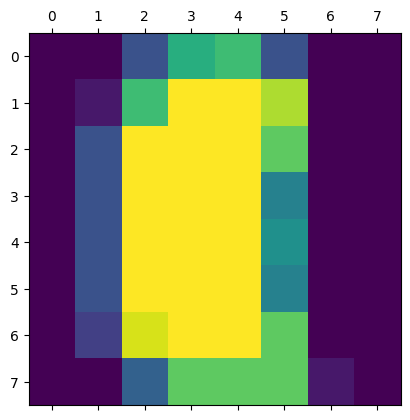

In [3]:
ordered_digits = digits.data[np.argsort(digits.data.sum(axis=1))]
ordered_target = digits.target[np.argsort(digits.data.sum(axis=1))]
plt.matshow(ordered_digits[-1].reshape((8,8)))

We can then divide up the dataset into slices of 400 samples, moving along in chunks of 150 to ensure that there are overlaps between consecutive slices. This will give us a list of ten different datasets that we can embed, with the goal being to ensure that the positions of points in the embeddings are relatively consistent.

In [4]:
slices = [ordered_digits[150 * i:min(ordered_digits.shape[0], 150 * i + 400)] for i in range(10)]

To ensure that consistency `AlignedUMAP` will need more information than just the datasets – we also need some information about how the datasets relate to one another. These take the form of dictionaries that relate the indices of one dataset to the indices of another. Currently `AlignedUMAP` only supports sequences of datasets with relations between each consecutive pair in the sequence. To construct the relations for this dataset we note that the last 250 samples of one dataset are going to be the same samples as the first 250 samples of the next dataset – this makes it easy to construct the dictionary: it is mapping

* 150 --> 0
* 151 --> 1
* ...
* 398 --> 248
* 399 --> 249

which we can construct easily using a dictionary comprehension. We will have the same relation between each consecutive pair, so to make the list of relations between pairs we can just duplicate the constructed relation the requisite number of times.

In [5]:
relation_dict = {i+150:i for i in range(400-150)}
relation_dicts = [relation_dict.copy() for i in range(len(slices) - 1)]

Note that while in this case the relation defines a map between identical samples in different datasets it can be much more general – see the politics example later for a case where the relation is constructed from external information (representatives names and states).

Now that we have both a list of data slices and a list of relations between the consecutive pairs we can use the `AlignedUMAP` class to generate a list of embeddings. The `AlignedUMAP` class takes most of the parameters that UMAP accepts. The major difference is that the fit method requires a list of datasets, and a keyword argument `relations` that specifies the relation dictionaries between consecutive pairs of datasets. Other than that things are essentially push-button.

In [6]:
%%time
aligned_mapper = umap.AlignedUMAP().fit(slices, relations=relation_dicts)

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/P

CPU times: user 34 s, sys: 1.96 s, total: 35.9 s
Wall time: 22.7 s


You will note that this took a non-trivial amount of time to run, despite being on the relatively small pendigits dataset. This is because we are completing 10 different UMAP embeddings at once, so on average we are taking about five seconds per embedding, which is more reasonable – the alignment does have overhead cost however.

The next step is to look at the results. To ensure that the plots we produce have a consistent x and y axis we’ll use a small function to compute a set of axis bounds for plotting.

In [7]:
def axis_bounds(embedding):
    left, right = embedding.T[0].min(), embedding.T[0].max()
    bottom, top = embedding.T[1].min(), embedding.T[1].max()
    adj_h, adj_v = (right - left) * 0.1, (top - bottom) * 0.1
    return [left - adj_h, right + adj_h, bottom - adj_v, top + adj_v]

Now it is just a matter of plotting the results in ten different scatter plots. We can do this most easily with matplotlib directly, setting up a grid of plots. Note that the progression proceeds by row then column, so read the progression as if you were reading a page of text (across, then down).

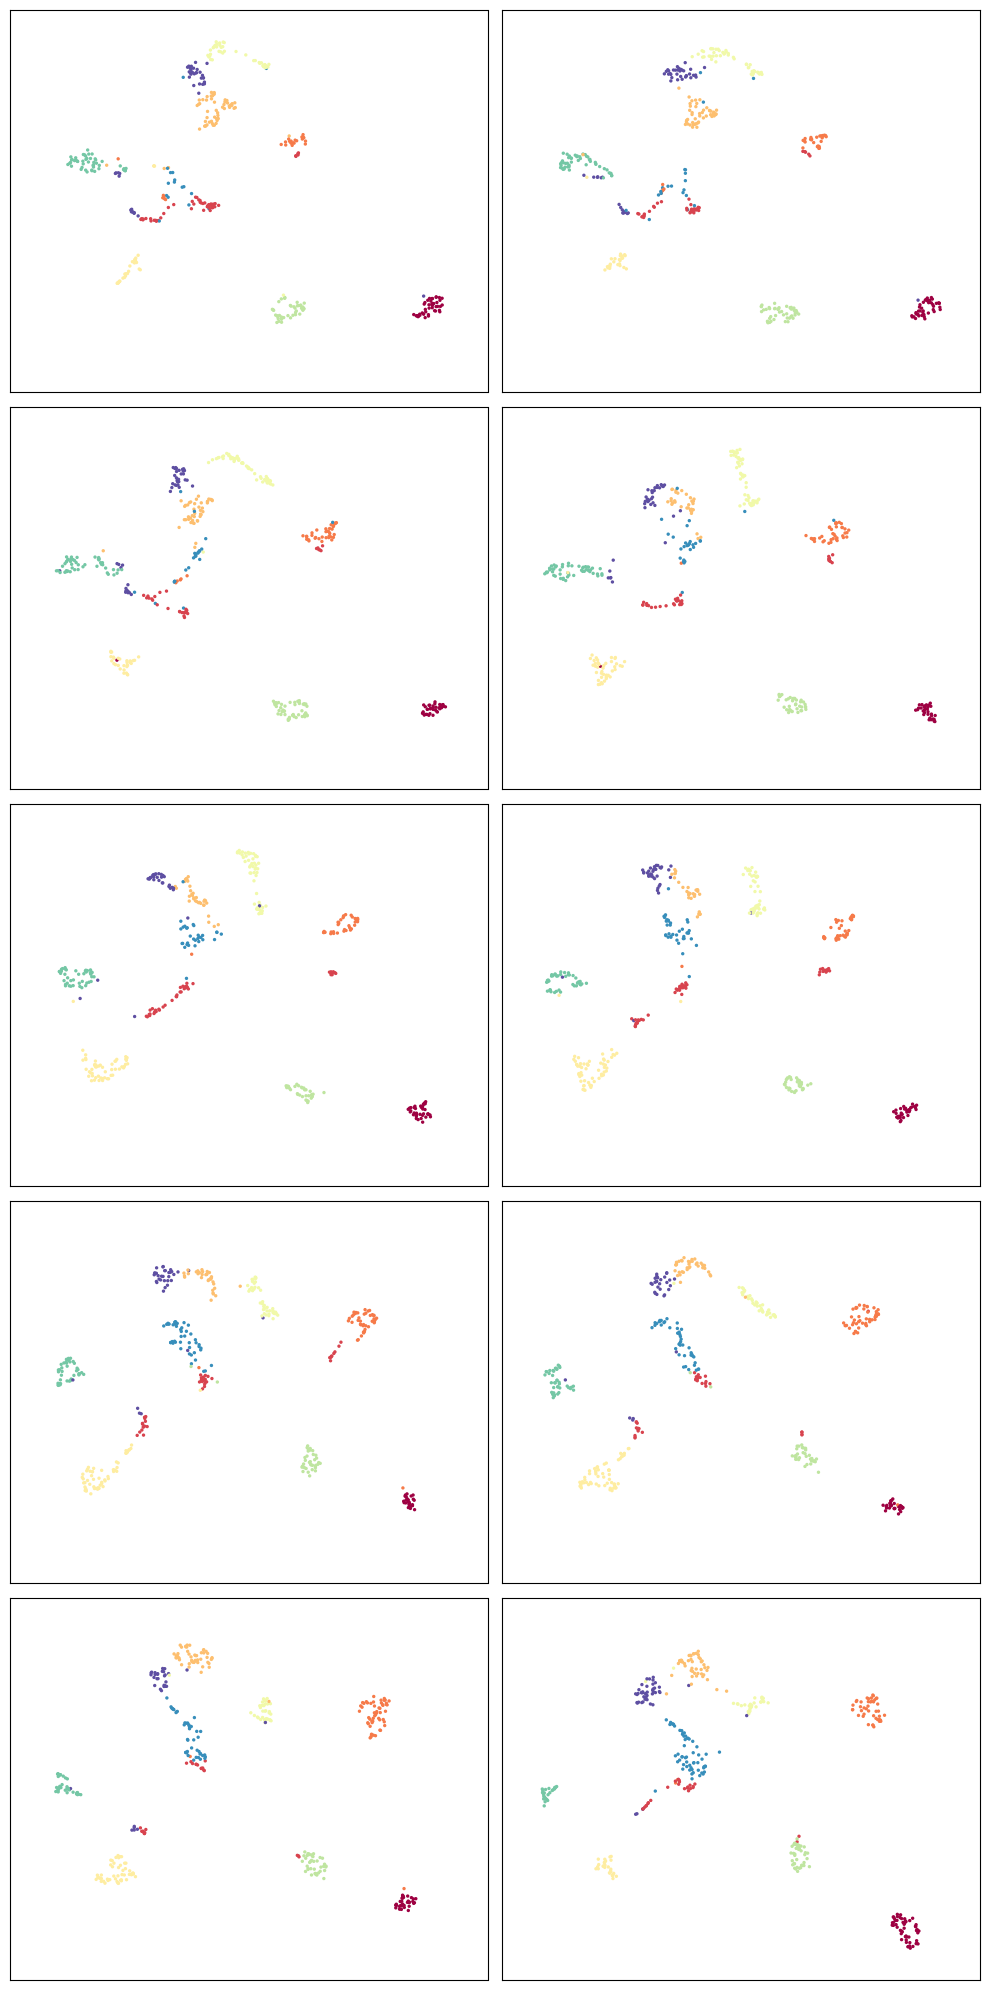

In [8]:
fig, axs = plt.subplots(5,2, figsize=(10, 20))
ax_bound = axis_bounds(np.vstack(aligned_mapper.embeddings_))
for i, ax in enumerate(axs.flatten()):
    current_target = ordered_target[150 * i:min(ordered_target.shape[0], 150 * i + 400)]
    ax.scatter(*aligned_mapper.embeddings_[i].T, s=2, c=current_target, cmap="Spectral")
    ax.axis(ax_bound)
    ax.set(xticks=[], yticks=[])
plt.tight_layout()

So despite being different embeddings on different datasets, the clusters keep their general alignment – the top left plot and bottom right plot have the same rough positions for specific digit clusters. We can also, to a degree, see how the structure changes over the course of the different slices. Thus we are keeping the various embeddings aligned, but allowing the changes dictated by the differing structures of each different slice of data.

## Online updating of aligned embeddings

It may be the case that we have incoming temporal data and would like to have embeddings of time-windows that, ideally, align with the embeddings of prior time-windows. As long as we overlap the time-windows we use to allow for relations between time windows then this is possible – except that the previous code required all the time-windows to be input at once for fitting. We would instead like to train an initial model and then update it as we go. This is possible via the `update` method which we’ll demonstrate below.

First we need to fit a base `AlignedUMAP` model; we’ll use the first two slices and the first relation dict to do so.

In [9]:
%%time
updating_mapper = umap.AlignedUMAP().fit(slices[:2], relations=relation_dicts[:1])


/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


CPU times: user 4.56 s, sys: 274 ms, total: 4.84 s
Wall time: 2.83 s


Note that this is fairly quick, since we are only fitting two slices. Given the trained model the update method requires a new slice of data to add, along with a relation dictionary (passed in with the `relations` keyword argument as with `fit`). This will append a new embedding to the `embeddings_` attribute of the model for the new data, aligned with what has been seen so far.

In [10]:
for i in range(2,len(slices)):
    %time updating_mapper.update(slices[i], relations={v:k for k,v in relation_dicts[i-1].items()})

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/aligned_umap.py:196: NumbaTypeSafetyWarning: unsafe cast from int64 to int32. Precision may be lost.
  if i in relation_dict:


CPU times: user 4.52 s, sys: 219 ms, total: 4.74 s
Wall time: 3.04 s


/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


CPU times: user 4.43 s, sys: 401 ms, total: 4.83 s
Wall time: 2.55 s


/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

CPU times: user 6.69 s, sys: 689 ms, total: 7.37 s
Wall time: 2.77 s


/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


CPU times: user 7.06 s, sys: 698 ms, total: 7.76 s
Wall time: 2.65 s


/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


CPU times: user 7.94 s, sys: 832 ms, total: 8.77 s
Wall time: 2.76 s


Note that each new slice takes a relatively short period of time, as we might hope. The downside of this, as you can imagine, is that we have no “forward” relations – the windows over slices only look backward. This means the results are less good, but we are trading that for the ability to quickly and easily update as we go.

We can look at how we did using essentially the same code as before.

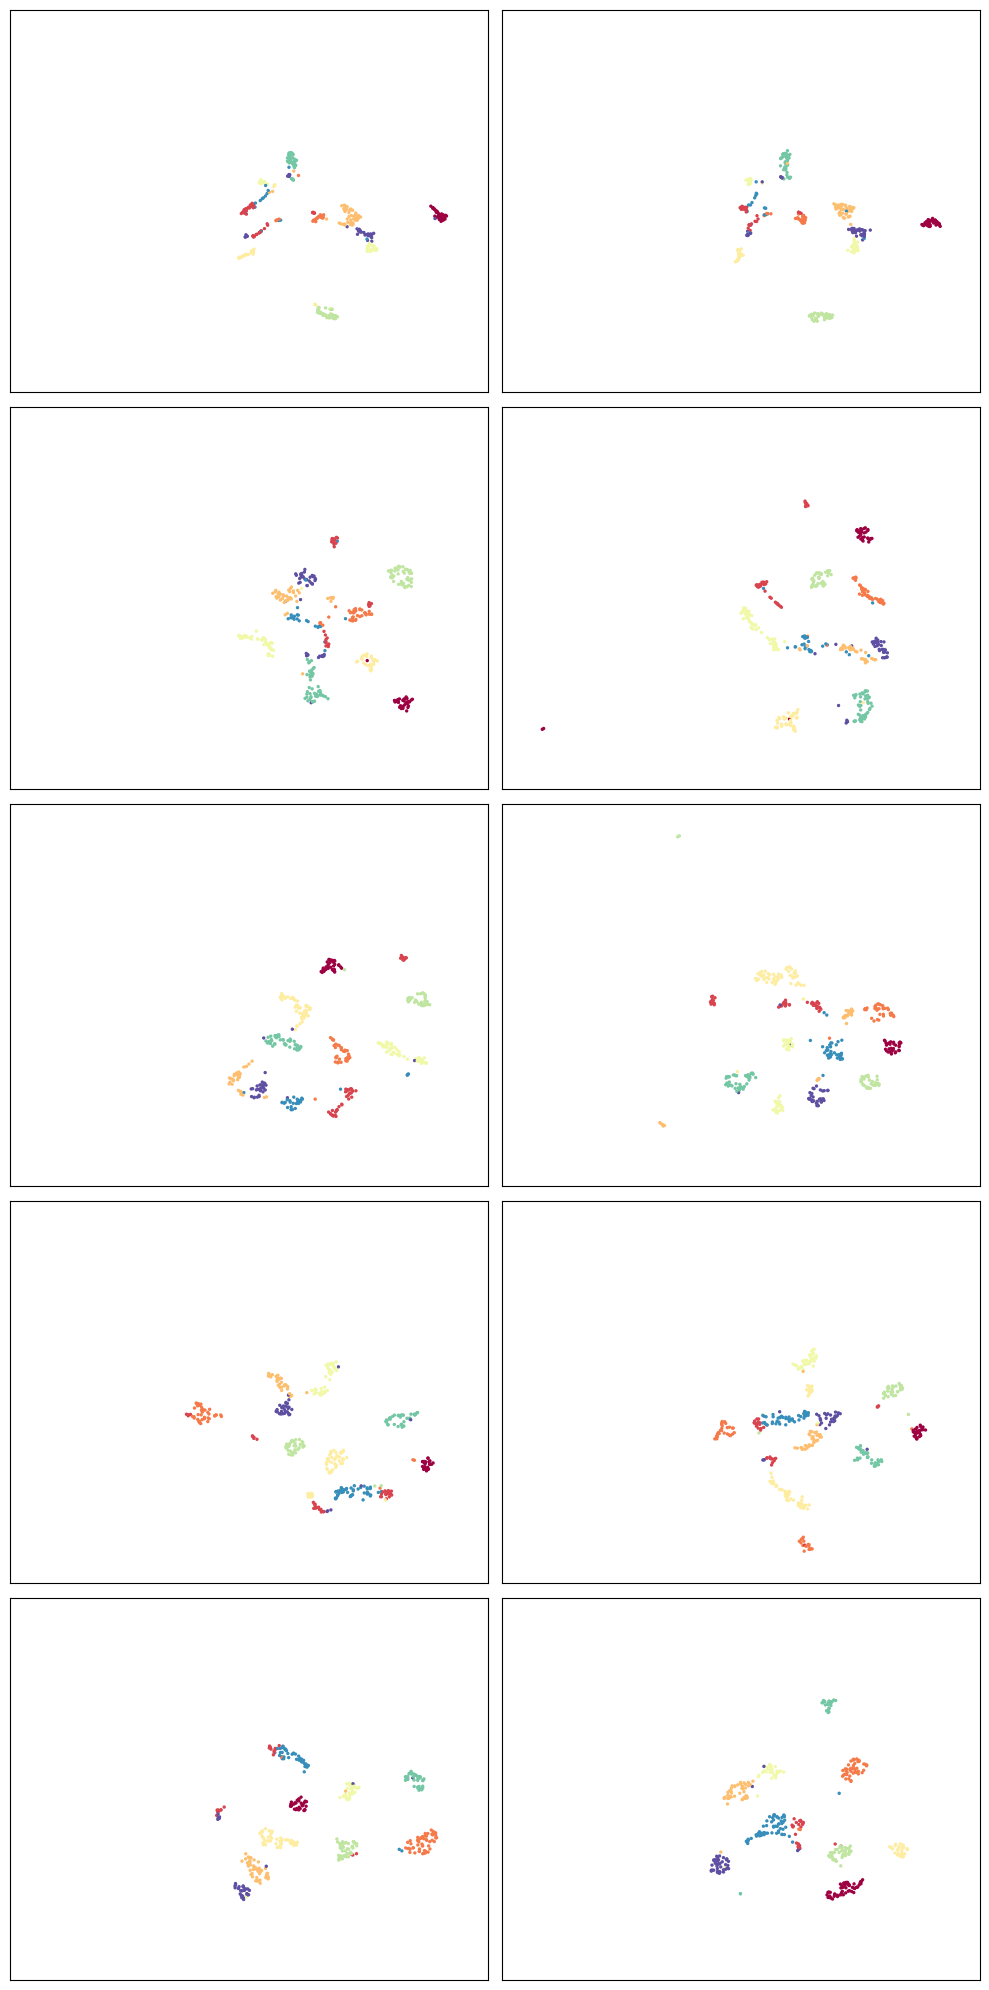

In [11]:
fig, axs = plt.subplots(5,2, figsize=(10, 20))
ax_bound = axis_bounds(np.vstack(updating_mapper.embeddings_))
for i, ax in enumerate(axs.flatten()):
    current_target = ordered_target[150 * i:min(ordered_target.shape[0], 150 * i + 400)]
    ax.scatter(*updating_mapper.embeddings_[i].T, s=2, c=current_target, cmap="Spectral")
    ax.axis(ax_bound)
    ax.set(xticks=[], yticks=[])
plt.tight_layout()

We see that the alignment is indeed working, so new slices remain comparable with previously trained slices. As noted the overall alignments and progression is not as nice as the previous version, but it does have the significant benefit of allowing an update as you go approach.

Note that right now this model keeps all the previous data, so it will only really work in a batch streaming approach where occasionally a fresh model is trained, dropping some of the historical data before continuing with updates.

## Aligning varying parameters

It is possible to align UMAP embedding that vary in the parameters used instead of the data. To demonstrate how this can work we’ll continue to use the pendigits dataset, but instead of slicing the data as we did before, we’ll use the full dataset. That means that our relations between datasets are simply constant relations. We can construct those ahead of time:

In [12]:
constant_dict = {i:i for i in range(digits.data.shape[0])}
constant_relations = [constant_dict for i in range(9)]



To run AlignedUMAP over a range of parameters you simply need to pass in a list of the sequence of parameters you wish to use. You can do this for several different parameters – just ensure that all the lists are the same length! In this case we’ll try looking at how the embeddings change if we change `n_neighbors` and `min_dist`. This means that when we create the AlignedUMAP object we pass a list, instead of a single value, to each of those parameters. To make the visualization a little more interesting we’ll also vary some of the alignment parameters (there are only two of major consequence). Specifically we’ll adjust the `alignment_window_size`, which controls how far forward and backward across the datasets we look when doing alignment, and the `alignment_regularisation` which controls how heavily we weight the alignment aspect versus the UMAP layout. Larger values of `alignment_regularisation` will work harder to keep points aligned across embeddings (at the cost of the embedding quality at each slice), while smaller values will allow the optimisation to focus more on the individual embeddings and put less emphasis on aligning the embeddings with each other.

Given a model we can then fit it. As before we need to hand it a list of datasets, and a list of relations. Since we are using the same data each time (and varying the parameters) we can just repeat the full pendigits dataset. Note that the number of datasets needs to match the number of parameter values being used. The same goes for the number of relations (one less than the number of parameter values).

In [13]:
neighbors_mapper = umap.AlignedUMAP(
    n_neighbors=[3,4,5,7,11,16,22,29,37,45,54],
    min_dist=[0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45],
    alignment_window_size=2,
    alignment_regularisation=1e-3,
).fit(
    [digits.data for i in range(10)], relations=constant_relations
)

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA

As before we can look at the results by plotting each of the embeddings.

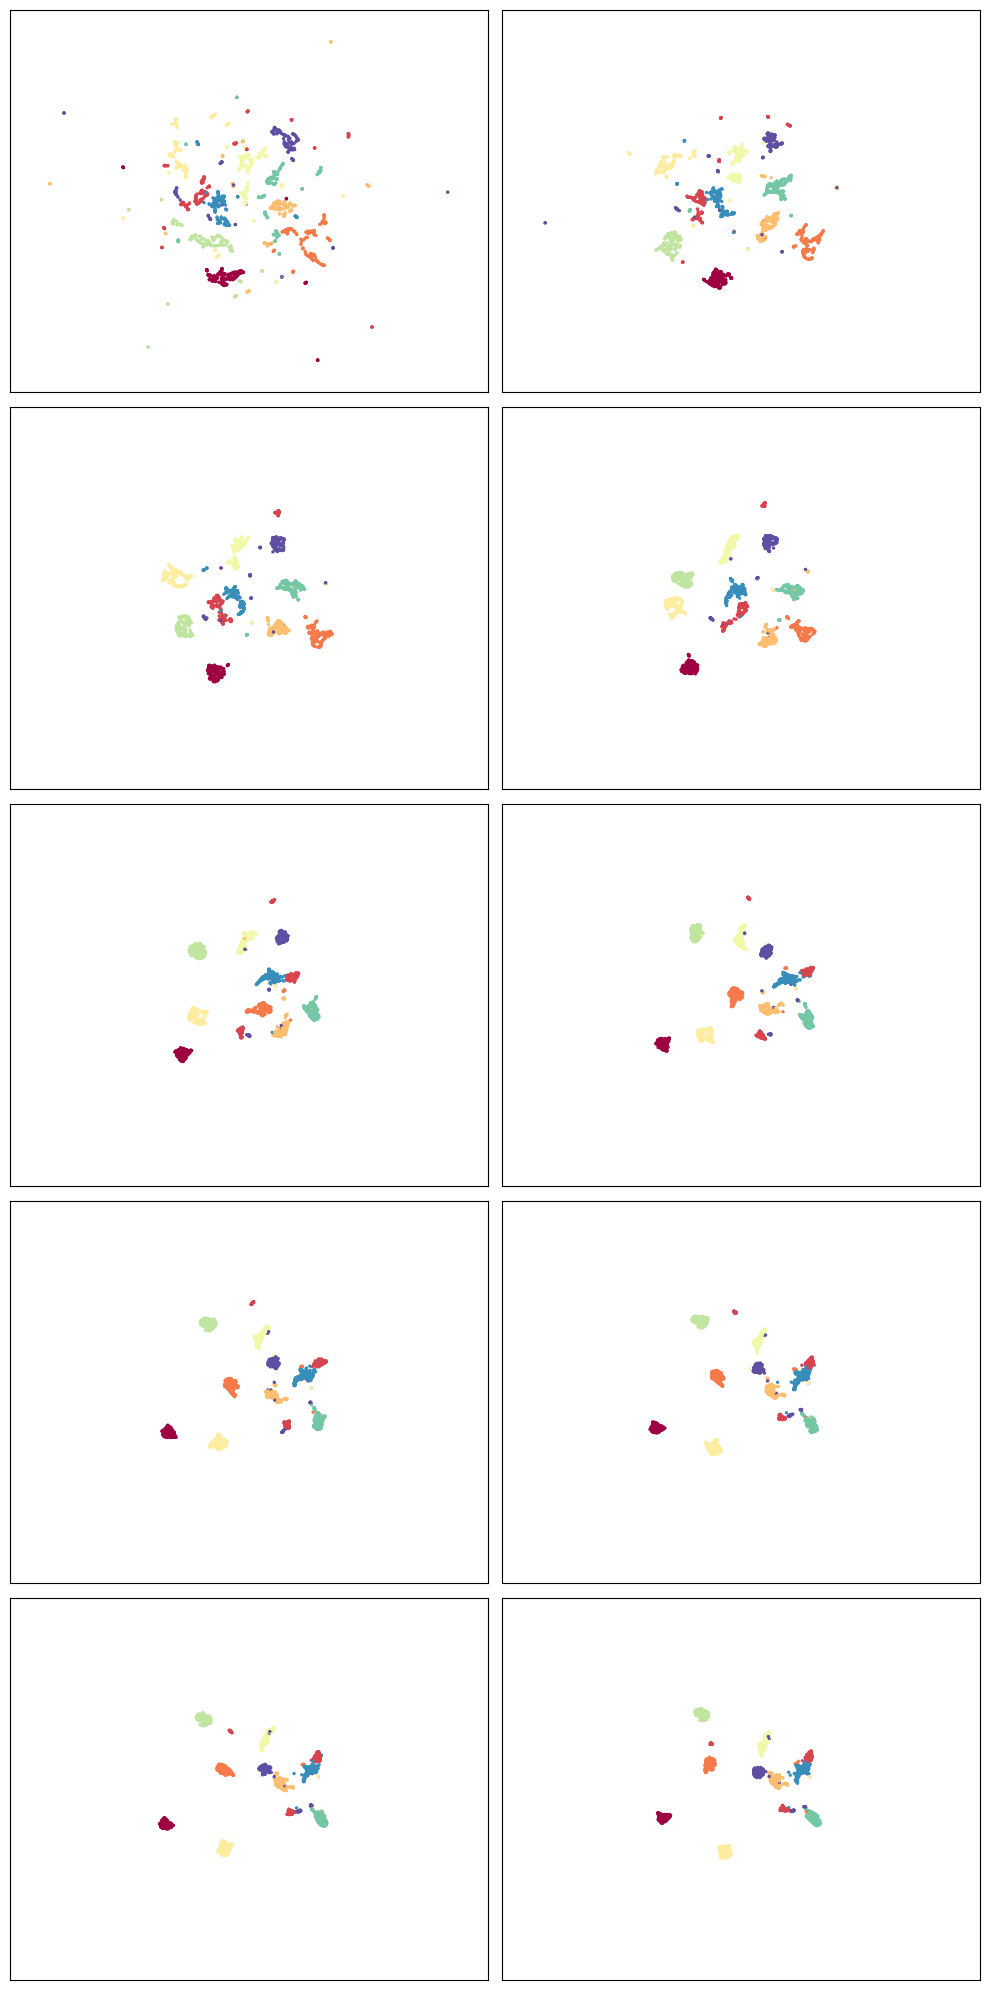

In [14]:
fig, axs = plt.subplots(5,2, figsize=(10, 20))
ax_bound = axis_bounds(np.vstack(neighbors_mapper.embeddings_))
for i, ax in enumerate(axs.flatten()):
    ax.scatter(*neighbors_mapper.embeddings_[i].T, s=2, c=digits.target, cmap="Spectral")
    ax.axis(ax_bound)
    ax.set(xticks=[], yticks=[])
plt.tight_layout()

To get a better feel for the evolution of the embedding over the change in parameter values we can plot the data in three dimensions, with the third dimension being the parameter value chosen. To better show how data points in the embedding *move* with respect to the changing parameters we can plot them not as points, but as *curves* connecting the same point in each sequential embedding. For three dimensional plots like this we’ll make use of the [plotly](https://plotly.com/) plotting library.

In [15]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd


The first thing we’ll have to do is wrangle the data into a suitable format for plotly. That’s the reason we loaded up pandas as well – plotly likes dataframes. This involves stacking all the embeddings together, and then assigning an extra z value according to which embedding we are in. For the purposes of visualization we’ll just have a linear scale from 0 to 1 of the appropriate length for the `z` coordinates.

In [16]:
n_embeddings = len(neighbors_mapper.embeddings_)
es = neighbors_mapper.embeddings_
embedding_df = pd.DataFrame(np.vstack(es), columns=('x', 'y'))
embedding_df['z'] = np.repeat(np.linspace(0, 1.0, n_embeddings), es[0].shape[0])
embedding_df['id'] = np.tile(np.arange(es[0].shape[0]), n_embeddings)
embedding_df['digit'] = np.tile(digits.target, n_embeddings)

The next thing we can do to improve the visualization is to smooth out the curves rather than leaving them as piecewise linear lines. To to this we can use the `scipy.interpolate` functionality to create smooth cubic splines that pass through all the points of the curve we wish to create.

In [17]:
import scipy.interpolate

The interpolate module has a function `interp1d` that generates a (vector of) smooth function given a one dimensional set of datapoints that it needs to pass through. We can generate separate functions for the x and y coordinates for each pendigit sample, allowing us to generate smooth curves in three dimensions.

In [18]:
fx = scipy.interpolate.interp1d(
    embedding_df.z[embedding_df.id == 0], embedding_df.x.values.reshape(n_embeddings, digits.data.shape[0]).T, kind="cubic"
)
fy = scipy.interpolate.interp1d(
    embedding_df.z[embedding_df.id == 0], embedding_df.y.values.reshape(n_embeddings, digits.data.shape[0]).T, kind="cubic"
)
z = np.linspace(0, 1.0, 100)

With that in hand it is just a matter of plotting all the curves. In plotly parlance each curve is a “trace” and we generate each one separately (along with a suitable colour given by the digit the sample represents). We then add all the traces to a figure, and display the figure.

In [19]:
palette = px.colors.diverging.Spectral
interpolated_traces = [fx(z), fy(z)]
traces = [
    go.Scatter3d(
        x=interpolated_traces[0][i],
        y=interpolated_traces[1][i],
        z=z*3.0,
        mode="lines",
        line=dict(
            color=palette[digits.target[i]],
            width=3.0
        ),
        opacity=1.0,
    )
    for i in range(digits.data.shape[0])
]
fig = go.Figure(data=traces)
fig.update_layout(
    width=800,
    height=700,
    autosize=False,
    showlegend=False,
)
fig.show()

Since it is tricky to get the interactive plotly figure embedded in documentation we have a static image here, but if you run this yourself you will have a fully interactive view of the data.

Alternatively, we can visualize the third dimension as an evolution of the embeddings through time by rendering each z-slice as a frame in an animated GIF. To do this, we’ll first need to import some notebook display tools and matplotlib’s [animation](https://matplotlib.org/stable/api/animation_api.html) module.

In [20]:
from IPython.display import display, Image, HTML
from matplotlib import animation

Next, we’ll create a new figure, initialize a blank scatter plot, then use `FuncAnimation` to update the point positions (called “offsets”) one frame at a time.

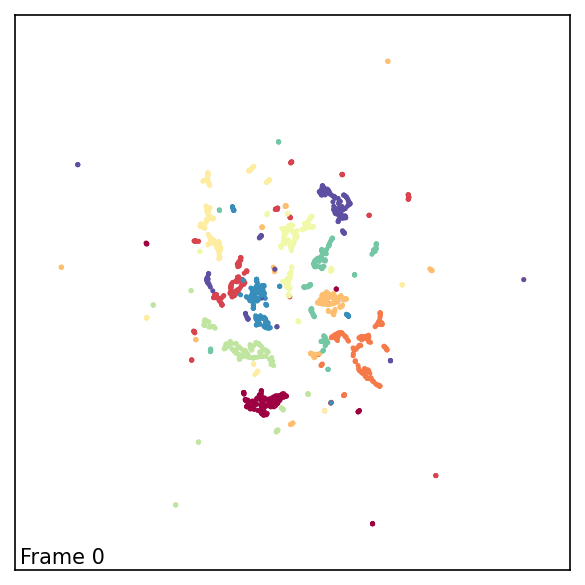

In [21]:
fig = plt.figure(figsize=(4, 4), dpi=150)
ax = fig.add_subplot(1, 1, 1)

scat = ax.scatter([], [], s=2)
scat.set_array(digits.target)
scat.set_cmap('Spectral')
text = ax.text(ax_bound[0] + 0.5, ax_bound[2] + 0.5, '')
ax.axis(ax_bound)
ax.set(xticks=[], yticks=[])
plt.tight_layout()

offsets = np.array(interpolated_traces).T
num_frames = offsets.shape[0]

def animate(i):
    scat.set_offsets(offsets[i])
    text.set_text(f'Frame {i}')
    return scat

anim = animation.FuncAnimation(
    fig,
    init_func=None,
    func=animate,
    frames=num_frames,
    interval=40)

Then we can save the animation as a GIF and close our animation. Depending on your machine, you may need to change which writer the save method uses.

In [22]:
anim.save("aligned_umap_pendigits_anim.gif", writer="pillow")
plt.close(anim._fig)

Finally, we can read in our rendered GIF and display it in the notebook.

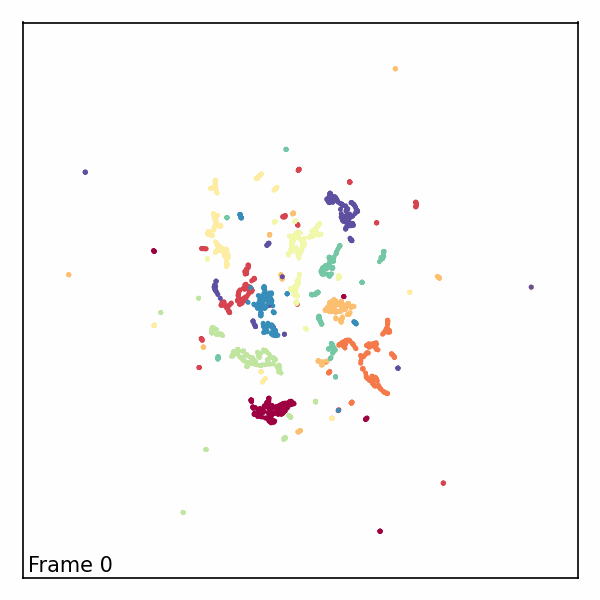

In [23]:
with open("aligned_umap_pendigits_anim.gif", "rb") as f:
    display(Image(f.read()))


© Copyright 2018, Leland McInnes.